### ML Assignment 2

#### Name: Bhagavatula Yogiraj
#### Roll No: 2025AA05028

## Indian Engineering Students' Placement Prediction

#### Dataset Description
This dataset contains synthetically generated data representing engineering students from Indian colleges. This dataset contains data regarding the student such as coding skill rating, gender, backlogs count etc. The target variable is "placement_status" which indicates whether the student got placed or not.

This dataset contains 5000 rows and 23 columns.

This dataset consists of 2 csv files:
1. 'indian engineering_students_placement_prediction.csv' - This file contains the main dataset with all the features.
2. 'placement_targets.csv' - This file contains the target variable "placement_status", "salary" for each student.

For this problem, I have removed the salary part and considered only the "placement_status" as the target variable for classification.

### Models used:
1. Logistic Regression
2. Random Forest
3. Decision Tree
4. KNN
5. GaussianNB
6. XGBoost

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df_features = pd.read_csv("indian_engineering_student_placement.csv")
df_features.head()

,Student_ID,gender,branch,cgpa,tenth_percentage,twelfth_percentage,backlogs,study_hours_per_day,attendance_percentage,projects_completed,...,aptitude_skill_rating,hackathons_participated,certifications_count,sleep_hours,stress_level,part_time_job,family_income_level,city_tier,internet_access,extracurricular_involvement
0,1,Male,ECE,8.74,74.0,75.0,0,3.8,71.1,7,...,5,4,5,6.5,8,Yes,Medium,Tier 2,Yes,Medium
1,2,Female,ECE,7.80,75.3,69.7,0,6.3,69.5,5,...,3,4,1,7.1,8,Yes,Medium,Tier 3,Yes,Low
2,3,Female,IT,6.95,62.8,68.3,0,1.5,62.5,8,...,4,6,3,6.1,2,No,Low,Tier 2,Yes,High
3,4,Male,ECE,7.46,57.9,51.4,1,4.7,64.6,6,...,4,2,2,7.3,7,No,Medium,Tier 1,Yes,Low
4,5,Male,IT,6.86,61.3,73.5,2,5.2,75.9,3,...,3,2,1,6.0,7,No,Medium,Tier 1,Yes,Medium


In [5]:
df_features.isnull().sum()

Student_ID                        0
gender                            0
branch                            0
cgpa                              0
tenth_percentage                  0
twelfth_percentage                0
backlogs                          0
study_hours_per_day               0
attendance_percentage             0
projects_completed                0
internships_completed             0
coding_skill_rating               0
communication_skill_rating        0
aptitude_skill_rating             0
hackathons_participated           0
certifications_count              0
sleep_hours                       0
stress_level                      0
part_time_job                     0
family_income_level               0
city_tier                         0
internet_access                   0
extracurricular_involvement    1006
dtype: int64

In [6]:
df_targets = pd.read_csv("placement_targets.csv")
df_targets.head()

,Student_ID,placement_status,salary_lpa
0,1,Placed,14.95
1,2,Placed,14.91
2,3,Placed,17.73
3,4,Placed,14.52
4,5,Placed,15.91


In [7]:
df = pd.merge(df_features, df_targets, on="Student_ID")

In [8]:
df.shape

(5000, 25)

In [9]:
df.head()

,Student_ID,gender,branch,cgpa,tenth_percentage,twelfth_percentage,backlogs,study_hours_per_day,attendance_percentage,projects_completed,...,certifications_count,sleep_hours,stress_level,part_time_job,family_income_level,city_tier,internet_access,extracurricular_involvement,placement_status,salary_lpa
0,1,Male,ECE,8.74,74.0,75.0,0,3.8,71.1,7,...,5,6.5,8,Yes,Medium,Tier 2,Yes,Medium,Placed,14.95
1,2,Female,ECE,7.80,75.3,69.7,0,6.3,69.5,5,...,1,7.1,8,Yes,Medium,Tier 3,Yes,Low,Placed,14.91
2,3,Female,IT,6.95,62.8,68.3,0,1.5,62.5,8,...,3,6.1,2,No,Low,Tier 2,Yes,High,Placed,17.73
3,4,Male,ECE,7.46,57.9,51.4,1,4.7,64.6,6,...,2,7.3,7,No,Medium,Tier 1,Yes,Low,Placed,14.52
4,5,Male,IT,6.86,61.3,73.5,2,5.2,75.9,3,...,1,6.0,7,No,Medium,Tier 1,Yes,Medium,Placed,15.91


In [10]:
df.isnull().sum()

Student_ID                        0
gender                            0
branch                            0
cgpa                              0
tenth_percentage                  0
twelfth_percentage                0
backlogs                          0
study_hours_per_day               0
attendance_percentage             0
projects_completed                0
internships_completed             0
coding_skill_rating               0
communication_skill_rating        0
aptitude_skill_rating             0
hackathons_participated           0
certifications_count              0
sleep_hours                       0
stress_level                      0
part_time_job                     0
family_income_level               0
city_tier                         0
internet_access                   0
extracurricular_involvement    1006
placement_status                  0
salary_lpa                        0
dtype: int64

In [11]:
df[df["extracurricular_involvement"].isnull()]

,Student_ID,gender,branch,cgpa,tenth_percentage,twelfth_percentage,backlogs,study_hours_per_day,attendance_percentage,projects_completed,...,certifications_count,sleep_hours,stress_level,part_time_job,family_income_level,city_tier,internet_access,extracurricular_involvement,placement_status,salary_lpa
16,17,Male,CSE,8.97,76.3,84.0,0,0.7,62.5,7,...,2,9.0,4,No,Low,Tier 2,Yes,NaN,Placed,20.00
17,18,Male,ECE,8.14,66.2,83.0,0,4.2,80.7,2,...,1,7.8,3,No,Low,Tier 3,No,NaN,Placed,13.70
29,30,Male,CSE,7.85,75.0,76.3,0,6.0,70.9,8,...,0,5.3,10,No,Medium,Tier 2,Yes,NaN,Placed,16.24
31,32,Male,ECE,8.19,78.2,67.9,0,4.9,77.2,5,...,1,6.0,5,No,High,Tier 3,Yes,NaN,Placed,17.94
37,38,Male,IT,8.45,79.4,65.9,0,3.8,73.9,8,...,3,6.2,4,No,Low,Tier 2,Yes,NaN,Placed,16.37
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4956,4957,Male,CE,8.01,74.4,69.3,1,3.3,76.6,7,...,3,6.3,10,Yes,High,Tier 3,Yes,NaN,Placed,16.35
4960,4961,Male,ME,7.97,75.7,71.0,1,2.5,70.5,7,...,5,6.0,6,Yes,Medium,Tier 2,Yes,NaN,Placed,15.71
4983,4984,Female,IT,7.89,71.6,69.7,2,5.4,74.1,7,...,6,5.7,10,No,Medium,Tier 2,Yes,NaN,Not Placed,0.00
4986,4987,Female,ECE,7.91,73.7,74.0,1,5.2,73.3,2,...,0,6.9,4,No,Medium,Tier 2,Yes,NaN,Not Placed,0.00


In [12]:
df["extracurricular_involvement"].unique()

array(['Medium', 'Low', 'High', nan], dtype=object)

In [13]:
df["extracurricular_involvement"] = df["extracurricular_involvement"].fillna("Unknown")

In [14]:
df.isnull().sum()

Student_ID                     0
gender                         0
branch                         0
cgpa                           0
tenth_percentage               0
twelfth_percentage             0
backlogs                       0
study_hours_per_day            0
attendance_percentage          0
projects_completed             0
internships_completed          0
coding_skill_rating            0
communication_skill_rating     0
aptitude_skill_rating          0
hackathons_participated        0
certifications_count           0
sleep_hours                    0
stress_level                   0
part_time_job                  0
family_income_level            0
city_tier                      0
internet_access                0
extracurricular_involvement    0
placement_status               0
salary_lpa                     0
dtype: int64

In [15]:
mapping = {
    "Low":1,
    "Medium":2,
    "High":3,
    "Unknown":0
}

df["extracurricular_involvement"] = df["extracurricular_involvement"].map(mapping)

In [16]:
df["extracurricular_involvement"].unique()

array([2, 1, 3, 0])

In [17]:
df["placement_status"].value_counts()

placement_status
Placed        4303
Not Placed     697
Name: count, dtype: int64

C:\Users\Yogiraj\AppData\Local\Temp\ipykernel_12632\1843026324.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='placement_status', y='cgpa', data=df, ax=axes[0,0], palette='Set2')
C:\Users\Yogiraj\AppData\Local\Temp\ipykernel_12632\1843026324.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='placement_status', y='coding_skill_rating', data=df, ax=axes[0,1], palette='Set2')
C:\Users\Yogiraj\AppData\Local\Temp\ipykernel_12632\1843026324.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='placement_status', y='internships_complete

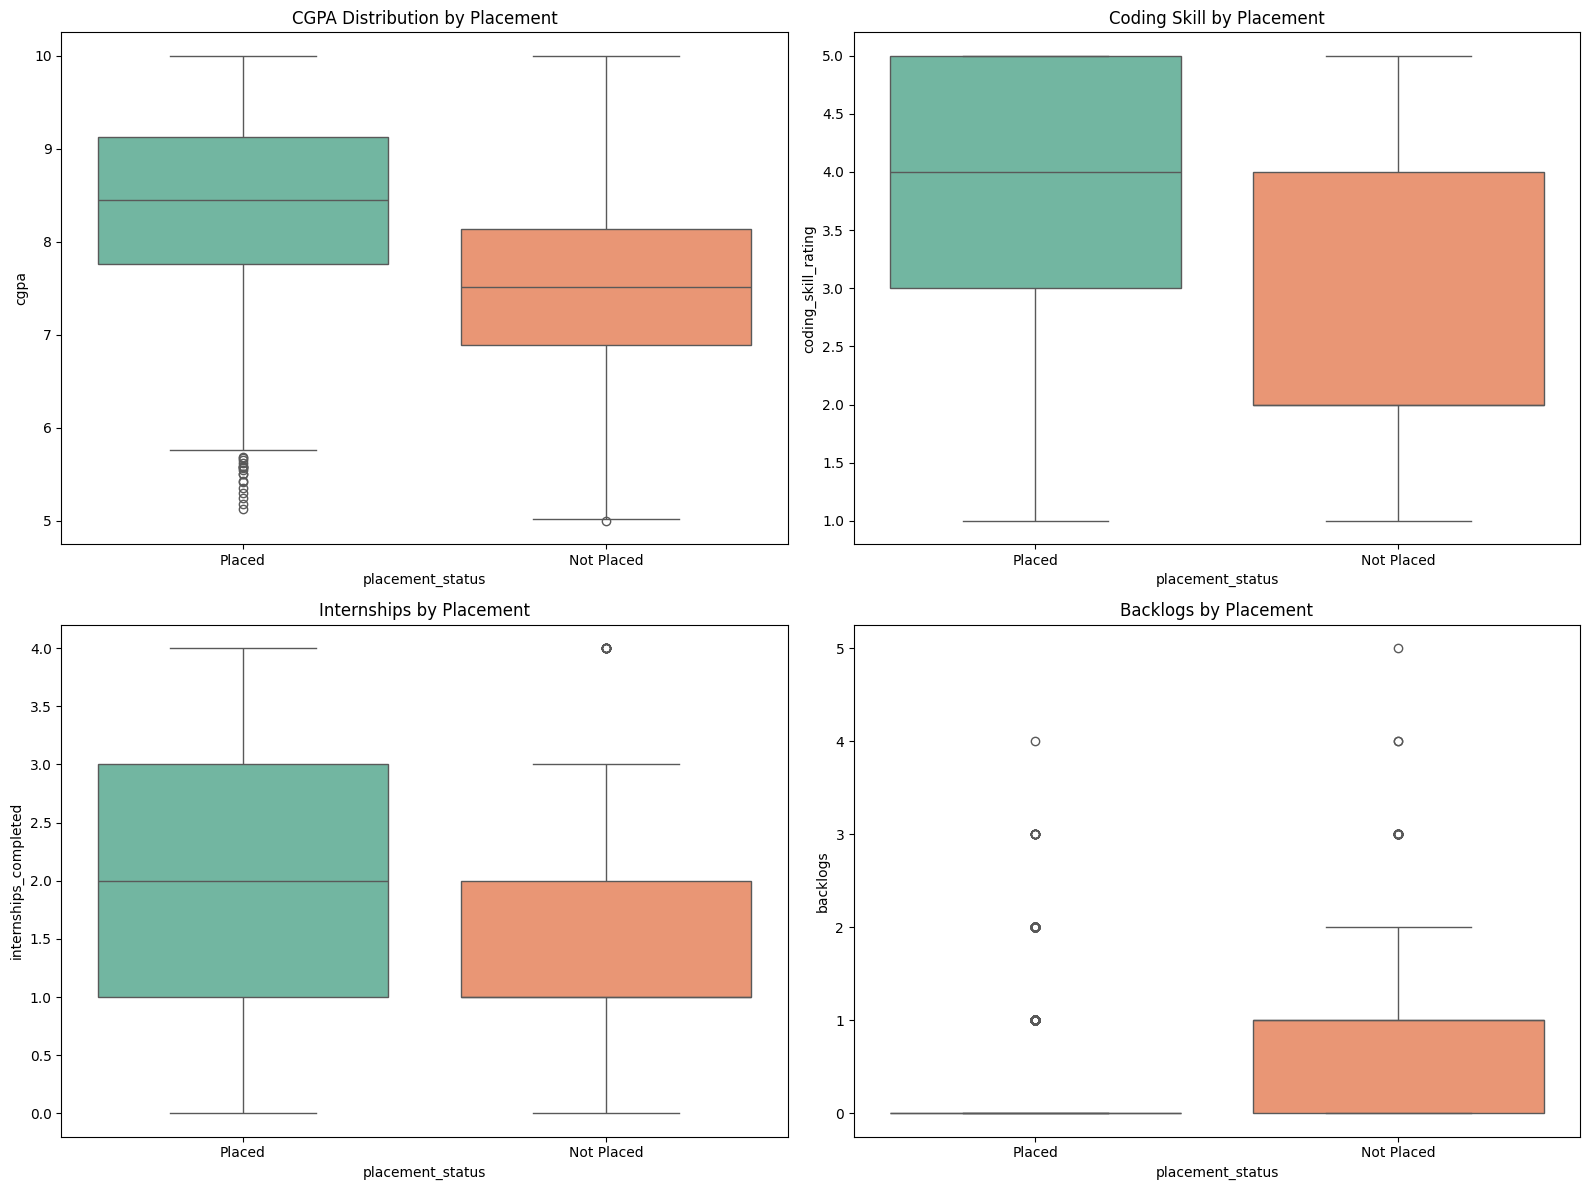

In [18]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

sns.boxplot(x='placement_status', y='cgpa', data=df, ax=axes[0,0], palette='Set2')
axes[0,0].set_title('CGPA Distribution by Placement')

sns.boxplot(x='placement_status', y='coding_skill_rating', data=df, ax=axes[0,1], palette='Set2')
axes[0,1].set_title('Coding Skill by Placement')

sns.boxplot(x='placement_status', y='internships_completed', data=df, ax=axes[1,0], palette='Set2')
axes[1,0].set_title('Internships by Placement')

sns.boxplot(x='placement_status', y='backlogs', data=df, ax=axes[1,1], palette='Set2')
axes[1,1].set_title('Backlogs by Placement')

plt.tight_layout()
plt.show()

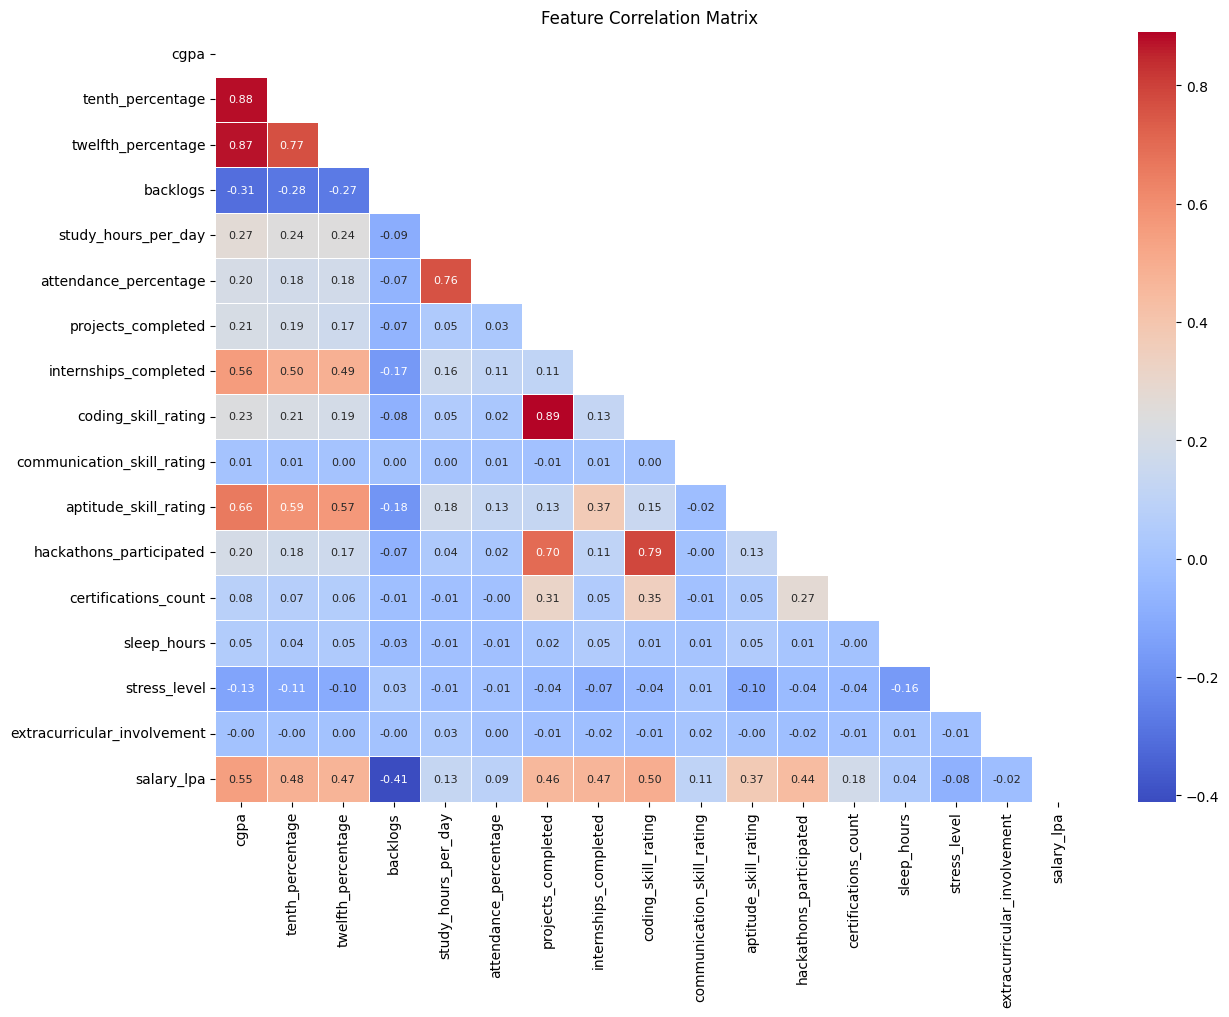

In [19]:
plt.figure(figsize=(14, 10))
# Select only numeric columns for correlation
numeric_df = df.select_dtypes(include=[np.number]).drop(columns=['Student_ID'])
corr = numeric_df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5, annot_kws={"size": 8})
plt.title('Feature Correlation Matrix')
plt.show()

In [20]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

In [21]:
X = df.drop(columns = ['Student_ID', 'placement_status', 'salary_lpa'])
y = df['placement_status'].apply(lambda x: 1 if x=="Placed" else 0)

In [22]:
X.columns

Index(['gender', 'branch', 'cgpa', 'tenth_percentage', 'twelfth_percentage',
       'backlogs', 'study_hours_per_day', 'attendance_percentage',
       'projects_completed', 'internships_completed', 'coding_skill_rating',
       'communication_skill_rating', 'aptitude_skill_rating',
       'hackathons_participated', 'certifications_count', 'sleep_hours',
       'stress_level', 'part_time_job', 'family_income_level', 'city_tier',
       'internet_access', 'extracurricular_involvement'],
      dtype='object')

In [23]:
X.head()

,gender,branch,cgpa,tenth_percentage,twelfth_percentage,backlogs,study_hours_per_day,attendance_percentage,projects_completed,internships_completed,...,aptitude_skill_rating,hackathons_participated,certifications_count,sleep_hours,stress_level,part_time_job,family_income_level,city_tier,internet_access,extracurricular_involvement
0,Male,ECE,8.74,74.0,75.0,0,3.8,71.1,7,3,...,5,4,5,6.5,8,Yes,Medium,Tier 2,Yes,2
1,Female,ECE,7.80,75.3,69.7,0,6.3,69.5,5,1,...,3,4,1,7.1,8,Yes,Medium,Tier 3,Yes,1
2,Female,IT,6.95,62.8,68.3,0,1.5,62.5,8,2,...,4,6,3,6.1,2,No,Low,Tier 2,Yes,3
3,Male,ECE,7.46,57.9,51.4,1,4.7,64.6,6,2,...,4,2,2,7.3,7,No,Medium,Tier 1,Yes,1
4,Male,IT,6.86,61.3,73.5,2,5.2,75.9,3,3,...,3,2,1,6.0,7,No,Medium,Tier 1,Yes,2


In [24]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42, stratify=y)

Let us perform the model classification all 6 models

In [26]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

In [27]:

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    matthews_corrcoef
)

In [28]:
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

In [29]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [30]:
categorical_cols = ['gender', 'branch', 'family_income_level', 'city_tier', 'internet_access', 'part_time_job', 'extracurricular_involvement']

numerical_cols = ['cgpa', 'tenth_percentage', 'twelfth_percentage', 'backlogs', 'study_hours_per_day', 
                  'attendance_percentage', 'projects_completed', 'internships_completed', 
                  'coding_skill_rating', 'communication_skill_rating', 'aptitude_skill_rating', 
                  'hackathons_participated', 'certifications_count', 'sleep_hours', 'stress_level']


In [31]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(drop='first'), categorical_cols)
    ]
)

In [38]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "KNN": KNeighborsClassifier(),
    "Gaussian NB": GaussianNB(),
    "Random Forest": RandomForestClassifier(random_state=42),
    "XGBoost": XGBClassifier(eval_metric='logloss', random_state=42)
}

In [39]:
results = []

In [40]:
import joblib

In [41]:
for name, model in models.items():
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('smote', SMOTE(random_state=42)),
        ('model', model)
    ])

    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    if hasattr(pipeline.named_steps['model'], "predict_proba"):
        y_prob = pipeline.predict_proba(X_test)[:, 1]
        auc = roc_auc_score(y_test, y_prob)
    else:
        auc = "N/A"

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    mcc = matthews_corrcoef(y_test, y_pred)

    results.append([name,acc, auc, prec, rec, f1, mcc])

    joblib.dump(pipeline, f"model_{name.replace(' ', '_').lower()}.pkl")

results_df = pd.DataFrame(results, columns=["Model", "Accuracy", "Precision", "Recall", "F1-Score", "AUC-ROC", "MCC"])

d:\Mtech\ML Assignment 2\env\lib\site-packages\sklearn\base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
d:\Mtech\ML Assignment 2\env\lib\site-packages\sklearn\base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
d:\Mtech\ML Assignment 2\env\lib\site-packages\sklearn\base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
d:\Mtech\ML Assignment 2\env\lib\site-packages\sklearn\base.py:474: Fu

In [44]:
results_df.head(6)

,Model,Accuracy,Precision,Recall,F1-Score,AUC-ROC,MCC
0,Logistic Regression,0.818,0.909513,0.980226,0.805104,0.884076,0.533759
1,Decision Tree,0.845,0.721418,0.925391,0.892111,0.908447,0.407561
2,KNN,0.726,0.836133,0.968153,0.705336,0.816107,0.399896
3,Gaussian NB,0.772,0.877299,0.971726,0.757541,0.851369,0.455370
4,Random Forest,0.869,0.890682,0.916762,0.932715,0.924669,0.423966
5,XGBoost,0.862,0.889245,0.916092,0.924594,0.920323,0.405721


In [43]:
# Use original dataframe BEFORE preprocessing
test_df = df.sample(1000, random_state=42)  # or use X_test_original if you have it

# Keep required columns only
required_columns = [
    'gender', 'branch', 'cgpa', 'tenth_percentage',
    'twelfth_percentage', 'backlogs', 'study_hours_per_day',
    'attendance_percentage', 'projects_completed',
    'internships_completed', 'coding_skill_rating',
    'communication_skill_rating', 'aptitude_skill_rating',
    'hackathons_participated', 'certifications_count',
    'sleep_hours', 'stress_level', 'part_time_job',
    'family_income_level', 'city_tier', 'internet_access',
    'extracurricular_involvement', 'placement_status'
]

test_df = test_df[required_columns]

# Convert placement_status to 0/1 if needed
test_df['placement_status'] = test_df['placement_status'].map({
    'Placed': 1,
    'Not Placed': 0
})

# Save
test_df.to_csv("test_data_streamlit.csv", index=False)

print("Test dataset saved successfully!")


Test dataset saved successfully!
